# Неделя 4 — Эксперимент A/B/C

Карточка недели: `docs/week4_experiment.md` · Полное описание: тетрадь, раздел 8

**Конвенция ячеек:**
- ячейка без пометки — готовый код, просто запустите
- `# TODO:` — здесь пишете вы

In [1]:
import sys

import numpy as np
import pandas as pd

sys.path.append('..')
from catboost import CatBoostClassifier
from src.validation import bootstrap_auc_diff, evaluate, split_by_time

dataset = pd.read_parquet('../data/processed/dataset.parquet')
train, valid, test = split_by_time(dataset)
print(len(train), len(test), len(valid))

66253 40265 35788


## 0. Одна функция на три подхода

Не копипастьте ячейки: различие между A, B и C должно быть только в наборе
признаков и в том, обучается одна модель или три. Всё остальное — один и тот же
dataset, один split, один seed, одни гиперпараметры.

In [2]:
def run_experiment(train, test, feature_cols, cat_cols, seed=42):
    """Обучает модель и возвращает вектор предсказаний на тесте."""
    # TODO
    x_train = train[feature_cols].copy()
    y_train = train["target"]

    x_test = test[feature_cols].copy()
    y_test = test["target"]

    cat_cols = [
        col for col in cat_cols
        if col in feature_cols
    ]
    for col in cat_cols:
        x_train[col] = x_train[col].fillna("unknown").astype(str)
        x_test[col] = x_test[col].fillna("unknown").astype(str)

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=seed,
        verbose=100,
        early_stopping_rounds=100
    )
    model.fit(
        x_train,
        y_train,
        cat_features=cat_cols,
        eval_set=(x_test, y_test),
        use_best_model=True
    )
    score = model.predict_proba(x_test)[:, 1]
    return model, score
    

## Подход A — единая модель без сегмента и продукта

In [3]:
# TODO
feature_cols_a = [
    col for col in dataset.columns
    if col not in [
        "client_id",
        "snapshot",
        "target",
        "segment",
        "product"
    ]
]
cat_cols_a = ["region"]

model_a, score_a = run_experiment(
    train, valid, feature_cols_a, cat_cols_a
)

metrics_a = evaluate(
    valid["target"], score_a, "Подход А"
)

0:	test: 0.8385025	best: 0.8385025 (0)	total: 78.7ms	remaining: 1m 18s
100:	test: 0.8898121	best: 0.8898121 (100)	total: 1.89s	remaining: 16.9s
200:	test: 0.8915595	best: 0.8915699 (199)	total: 3.84s	remaining: 15.3s
300:	test: 0.8927499	best: 0.8927648 (299)	total: 5.99s	remaining: 13.9s
400:	test: 0.8932571	best: 0.8933087 (362)	total: 7.8s	remaining: 11.7s
500:	test: 0.8932492	best: 0.8935691 (469)	total: 9.62s	remaining: 9.58s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.893569087
bestIteration = 469

Shrink model to first 470 iterations.
--- Подход А ---
ROC-AUC: 0.8936
PR-AUC: 0.7827
Precision@10%: 0.6931
Lift@10%: 7.49x
Доля оттока: 0.0925


## Подход B — единая модель + сегмент и продукт как признаки

In [4]:
# TODO
feature_cols_b = [
    col for col in dataset.columns
    if col not in [
        "client_id",
        "snapshot",
        "target",
    ]
]
cat_cols_b = ["region", "segment", "product"]

model_b, score_b = run_experiment(
    train, valid, feature_cols_b, cat_cols_b
)

metrics_b = evaluate(
    valid["target"], score_b, "Подход B"
)

0:	test: 0.8578341	best: 0.8578341 (0)	total: 23.9ms	remaining: 23.9s
100:	test: 0.8892437	best: 0.8892437 (100)	total: 2.73s	remaining: 24.3s
200:	test: 0.8910114	best: 0.8911073 (169)	total: 5.21s	remaining: 20.7s
300:	test: 0.8922918	best: 0.8922918 (300)	total: 7.46s	remaining: 17.3s
400:	test: 0.8927249	best: 0.8928104 (385)	total: 9.59s	remaining: 14.3s
500:	test: 0.8931464	best: 0.8931601 (495)	total: 11.7s	remaining: 11.7s
600:	test: 0.8929441	best: 0.8931684 (504)	total: 13.8s	remaining: 9.19s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8931684427
bestIteration = 504

Shrink model to first 505 iterations.
--- Подход B ---
ROC-AUC: 0.8932
PR-AUC: 0.7854
Precision@10%: 0.6923
Lift@10%: 7.48x
Доля оттока: 0.0925


## Подход C — отдельная модель на каждый сегмент

Предсказания трёх моделей склеиваются в ОДИН вектор по исходному порядку строк
теста — иначе метрики несравнимы с A и B.

Если в сегменте меньше 100 примеров оттока в обучении — выведите предупреждение.

In [5]:
# TODO
score_c = pd.Series(
    index=valid.index,
    dtype=float
)

for segment in sorted(train["segment"].unique()):
    train_segment = train[
        train["segment"] == segment
        ]
    valid_segment = valid[
    valid["segment"] == segment
        ]

    churn_count = train_segment["target"].sum()

    print(segment, "клиентов: ", len(train_segment), "оттоков: ", churn_count)

    if churn_count < 100:
        print("Внимание в сегменте осталось меньше 100 оттоков")

    segment_model, segment_score = run_experiment(
        train_segment, valid_segment, feature_cols_b, cat_cols_b
    )
    score_c.loc[valid_segment.index] = segment_score

assert score_c.isna().sum() == 0

metrics_c = evaluate(
    valid["target"],
    score_c.loc[valid.index].to_numpy(), "подход С"
)

крупный бизнес клиентов:  11935 оттоков:  526
0:	test: 0.8062537	best: 0.8062537 (0)	total: 9.26ms	remaining: 9.25s
100:	test: 0.8824184	best: 0.8848899 (2)	total: 746ms	remaining: 6.64s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8848899433
bestIteration = 2

Shrink model to first 3 iterations.
малый бизнес клиентов:  31712 оттоков:  2927
0:	test: 0.8246043	best: 0.8246043 (0)	total: 12.7ms	remaining: 12.7s
100:	test: 0.8809403	best: 0.8810981 (96)	total: 1.29s	remaining: 11.5s
200:	test: 0.8831169	best: 0.8831169 (200)	total: 2.36s	remaining: 9.37s
300:	test: 0.8840548	best: 0.8840548 (300)	total: 3.44s	remaining: 7.98s
400:	test: 0.8847187	best: 0.8850241 (372)	total: 4.49s	remaining: 6.7s
500:	test: 0.8848466	best: 0.8851000 (415)	total: 5.57s	remaining: 5.54s
600:	test: 0.8858673	best: 0.8859272 (596)	total: 6.65s	remaining: 4.41s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8859271809
bestIteration = 596

Shrink model to first 597 

## Сравнение: в целом и по сегментам

TODO: таблица ROC-AUC и Lift@10% для A/B/C — общая и внутри каждого сегмента.

Ожидаемо: различия в целом невелики, подход C проседает на сегменте
«крупный бизнес» — там меньше всего данных.

In [6]:
# TODO
predictions = valid[
    ["segment", "target"]
    ].copy()
predictions["A"] = score_a
predictions["B"] = score_b
predictions["C"] = score_c.loc[valid.index].to_numpy()

rows = []

scopes = ["Все"] + sorted(
    predictions["segment"].unique()
)

for scope in scopes:
    if scope == "Все":
        part = predictions
    else:
        part = predictions[
            predictions["segment"] == scope
        ]

    for approach in ["A", "B", "C"]:
        metrics = evaluate(
            part["target"],
            part[approach],
            f"{approach} — {scope}"
        )

        rows.append({
            "Сегмент": scope,
            "Подход": approach,
            "ROC-AUC": metrics["roc_auc"],
            "PR-AUC": metrics["pr_auc"],
            "Lift@10%": metrics["lift_at_10"]
        })

comparison = pd.DataFrame(rows)

comparison.round(4)

--- A — Все ---
ROC-AUC: 0.8936
PR-AUC: 0.7827
Precision@10%: 0.6931
Lift@10%: 7.49x
Доля оттока: 0.0925
--- B — Все ---
ROC-AUC: 0.8932
PR-AUC: 0.7854
Precision@10%: 0.6923
Lift@10%: 7.48x
Доля оттока: 0.0925
--- C — Все ---
ROC-AUC: 0.8614
PR-AUC: 0.7304
Precision@10%: 0.6395
Lift@10%: 6.91x
Доля оттока: 0.0925
--- A — крупный бизнес ---
ROC-AUC: 0.8850
PR-AUC: 0.7769
Precision@10%: 0.4518
Lift@10%: 7.63x
Доля оттока: 0.0592
--- B — крупный бизнес ---
ROC-AUC: 0.8844
PR-AUC: 0.7778
Precision@10%: 0.4564
Lift@10%: 7.70x
Доля оттока: 0.0592
--- C — крупный бизнес ---
ROC-AUC: 0.8849
PR-AUC: 0.7123
Precision@10%: 0.4319
Lift@10%: 7.29x
Доля оттока: 0.0592
--- A — малый бизнес ---
ROC-AUC: 0.8873
PR-AUC: 0.7881
Precision@10%: 0.7919
Lift@10%: 7.35x
Доля оттока: 0.1078
--- B — малый бизнес ---
ROC-AUC: 0.8860
PR-AUC: 0.7881
Precision@10%: 0.7913
Lift@10%: 7.34x
Доля оттока: 0.1078
--- C — малый бизнес ---
ROC-AUC: 0.8859
PR-AUC: 0.7867
Precision@10%: 0.7895
Lift@10%: 7.32x
Доля оттока: 0.

,Сегмент,Подход,ROC-AUC,PR-AUC,Lift@10%
0,Все,A,0.8936,0.7827,7.4896
1,Все,B,0.8932,0.7854,7.4805
2,Все,C,0.8614,0.7304,6.9098
3,крупный бизнес,A,0.8850,0.7769,7.6262
4,крупный бизнес,B,0.8844,0.7778,7.7038
5,крупный бизнес,C,0.8849,0.7123,7.2902
6,малый бизнес,A,0.8873,0.7881,7.3458
7,малый бизнес,B,0.8860,0.7881,7.3404
8,малый бизнес,C,0.8859,0.7867,7.3240
9,средний бизнес,A,0.8806,0.7732,7.4501


## Значимость различий

Смотрим на доверительный интервал разницы AUC, а не на «кто чаще выиграл».
Если интервал накрывает ноль — различия нет, и это полноценный ответ.

In [7]:

# bootstrap_auc_diff(test['target'], score_b, score_c)
bootstrap_b_vs_a = bootstrap_auc_diff(valid["target"], score_b, score_a)
bootstrap_b_vs_c = bootstrap_auc_diff(valid["target"], score_b, score_c.loc[valid.index].to_numpy())

Средняя разница AUC = -0.0004, 95% интервал [-0.0015, +0.0006]
Различие НЕ значимо: интервал накрывает ноль
Средняя разница AUC = +0.0317, 95% интервал [+0.0262, +0.0369]
Различие значимо


## Интерпретация: importance + SHAP

SHAP на 50 000 строк считается долго — берите подвыборку 2000–5000 строк.
Если в топе оказался технический идентификатор — это сигнал утечки, а не находка.

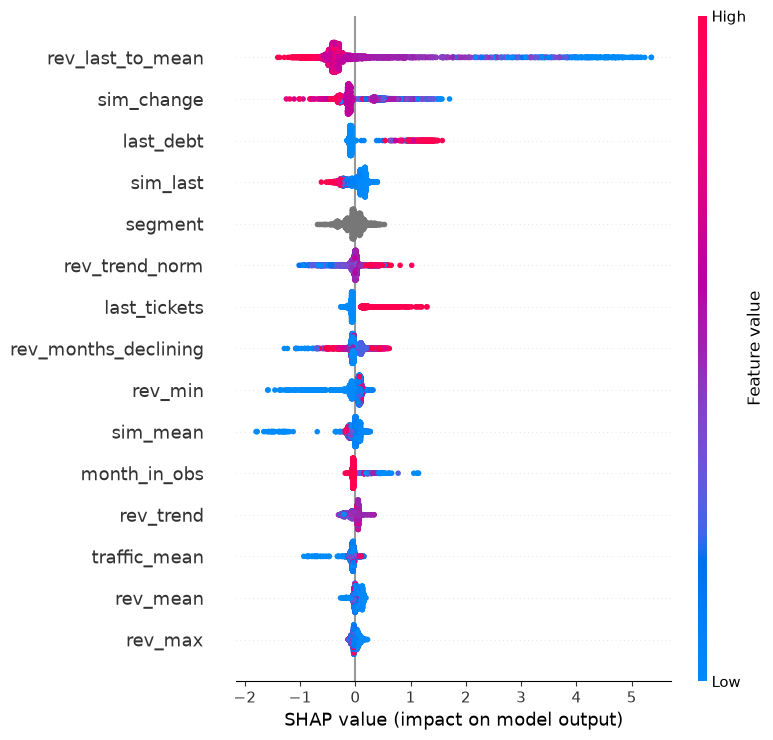

client_id: CL003097
риск: 0.9976
реальный target: 1


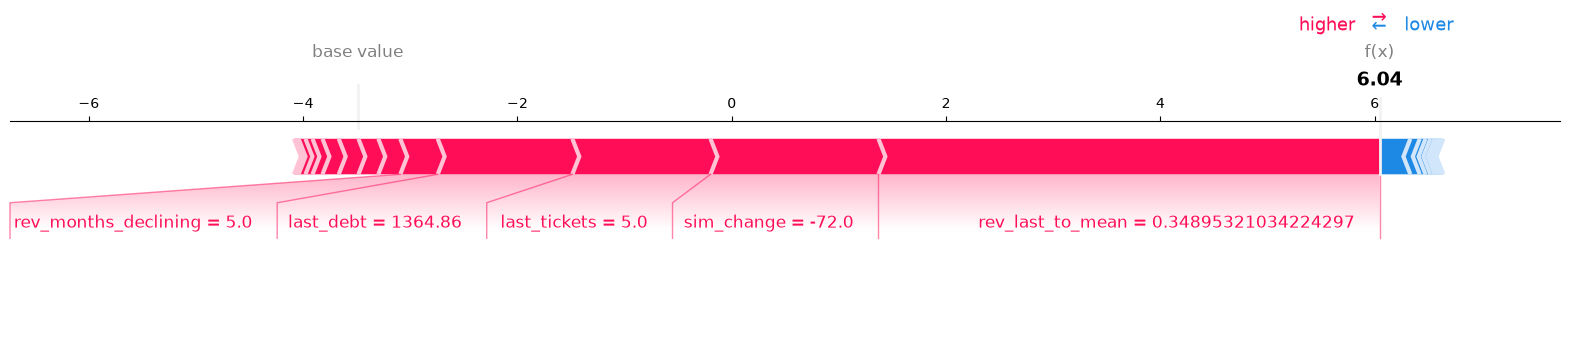

client_id: CL010385
риск: 0.9974
реальный target: 1


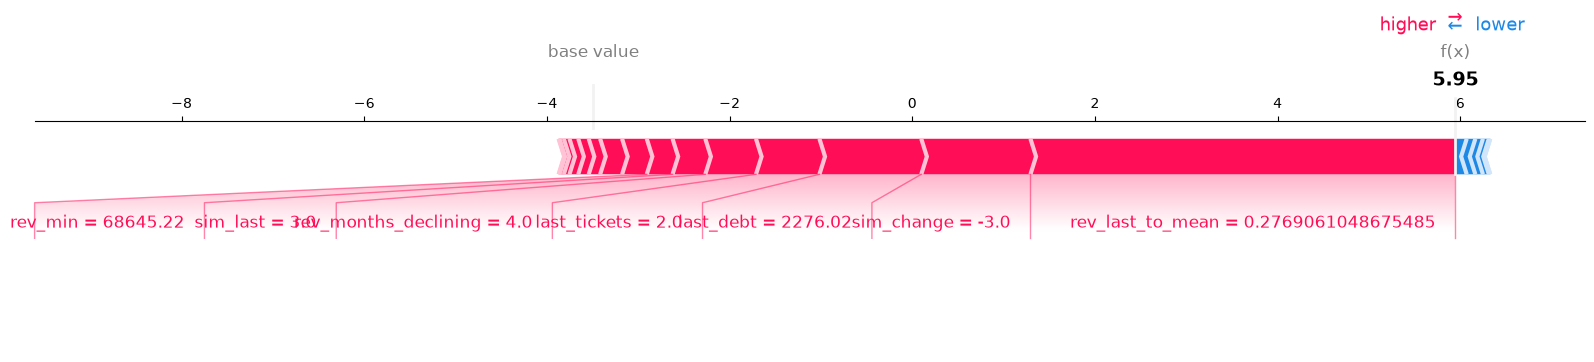

In [8]:
from catboost import Pool
import shap

importance = pd.DataFrame({
    "feature": feature_cols_b,
    "importance": model_b.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)
importance.head(15)

shap_sample = valid[feature_cols_b].sample(n=3000, random_state=42).copy()

for col in cat_cols_b:
    shap_sample[col] = (shap_sample[col].fillna("unknown").astype(str))

shap_pool = Pool(shap_sample, cat_features=cat_cols_b)

explainer = shap.TreeExplainer(model_b)

shap_values = explainer.shap_values(shap_pool)

shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=15
)


shap.initjs()
sample_scores = model_b.predict_proba(
    shap_pool
)[:, 1]

top_positions = np.argsort(
    -sample_scores
)[:2]

for position in top_positions:
    row_index = shap_sample.index[position]

    print(
        "client_id:",
        valid.loc[row_index, "client_id"]
    )
    print(
        "риск:",
        round(sample_scores[position], 4)
    )
    print(
        "реальный target:",
        valid.loc[row_index, "target"]
    )

    shap.force_plot(
        explainer.expected_value,
        shap_values[position],
        shap_sample.iloc[position],
        matplotlib=True
    )

## Вывод

Подход B показал лучший PR-AUC = 0,7854. У подхода A чуть выше ROC-AUC = 0,8936 и Lift@10% = 7,49x, но различие между A и B статистически незначимо.

Bootstrap для B против A дал разницу AUC = -0,0004 и 95% интервал [-0,0015; 0,0006]. Интервал накрывает ноль, поэтому доказанного различия между A и B нет.

Подход C значимо хуже B: ROC-AUC = 0,8614 и Lift@10% = 6,91x. Разница AUC равна 0,0317, 95% интервал [0,0262; 0,0369] не накрывает ноль.

Рекомендуется использовать единую модель B с сегментом и продуктом в качестве признаков. Отдельные модели для каждого сегмента не нужны.